In [10]:
import numpy as np 
import matplotlib.pyplot as plt 
from FW2D import DataInterface
from FW2D.processing.fit_utils import * 
from FW2D.processing.sigprocessing import get_normalized_complex_signal
from fullwave2d.config.definitions import DATA_FDOP_DIR, LPP_palette
from fullwave2d.core.wrapper import InputData

from matlabtools import Struct
from scipy import constants as cnst


mi = 6 * cnst.m_p #kg
Te = 1800 #eV
B = 1.0 #T
cs = np.sqrt(cnst.e * Te / mi)
OmegaI = cnst.e * B / mi
rhos = cs / OmegaI

import h5py 

In [11]:
def compute_profile(out):
    from scipy import constants as cnst

    val = out.validated == 1
    out.kp = 4 * np.pi * out.freqGHz * 1e9 / cnst.c * np.sin(out.theta * np.pi / 180) / 100 # cm-1

    out.v_perp = (2 * np.pi * out.fDop) / (out.kp * 1e2)
    out.dv_perp = (2 * np.pi * out.dfDop) / (out.kp * 1e2)
    out.v_min= (2 * np.pi * out.fDop_min) / (out.kp * 1e2)
    out.v_max = (2 * np.pi * out.fDop_max) / (out.kp * 1e2)
    out.yerr = np.array([np.abs(out.v_min - out.v_perp),
                                np.abs(out.v_max - out.v_perp)])
    out.val = val
    ET = np.zeros_like(out.fDop)
    EL  = np.copy(ET)
    EG  = np.copy(ET)
    NormS  = np.copy(ET)

    
    for i, s in enumerate(out.specobjs):
        
        if val[i]:
            xfit = np.linspace(s.f.min(), s.f.max(), 1000)
            Tfit = taylor(xfit / s.xscale, *s.fit_params.taylor, dt=s.dt * s.xscale) * s.yscale + s.P_noise
            Lfit = lorentzian(xfit / s.xscale, *s.fit_params.lorentzian,) * s.yscale + s.P_noise
            Gfit = gaussian(xfit / s.xscale, *s.fit_params.gaussian,) * s.yscale + s.P_noise
            ET[i] = np.trapz(Tfit, xfit )
            EL[i] = np.trapz(Lfit, xfit )
            EG[i] = np.trapz(Gfit, xfit )
            NormS[i] = s.NormS
            
            if ET[i] < 0.1 * s.rms:
                ET[i] = np.mean([EL[i], EG[i], NormS[i]])
        
            dET = np.std([ET, EG, EL, NormS], axis = 0)
            
    out.ET  = ET
    out.dET = dET
        
    return out

def get_ncrit(f0, angle=0.0):
    """
    Critical density for vacuum-frequency f0 [Hz] for
    O/X-mode and incidence angle [degrees].
    """
    # eps0 * m_e * (2 pi)² /e² [SI units] = 0.012404426
    return f0**2 * 0.012404426 * np.cos(np.deg2rad(angle))

In [12]:
def cross_corr(a, b):
    a = (a - np.mean(a)) / np.std(a)
    b = (b - np.mean(b)) / np.std(b)
    return np.real(np.mean(a * np.conj(b)))

In [9]:
import pickle 

filename = '/home/FO278650/Bureau/FullWave2D_FO/data/fw2d_irene/HW_RCR_C1.0_51/HW_test_f49_angle10_waist300/input.pkl'

with open(filename, "rb") as f:
    inp = pickle.load(f)

inp.subdir = 'HW_RCR_C1.0_51'

with open(filename, "wb") as f:
    pickle.dump(inp, f)

In [128]:
subdir, machine = 'HW_RCR_C1.0_49', 'irene'

dI = DataInterface(subdir, machine = machine)
isim_ref = 4

In [130]:
fdop = Struct.from_mat(DATA_FDOP_DIR.joinpath(f'{subdir}.mat'), 'outp')
out = compute_profile(fdop)

In [102]:
flname = '/home/FO278650/Zone_Travail/HWAK/simu_hwak/4096_4096_C1.0.h5'
it = 8
with h5py.File(flname, 'r', libver='latest', swmr=True) as fl:

    #Construct the real space grid
    Lx, Ly = fl['params/Lx'][()], fl['params/Ly'][()]
    Npx, Npy = fl['params/Npx'][()], fl['params/Npy'][()]
    Nx, Ny, Nxh, Nyh = int(Npx/3)*2, int(Npy/3)*2, int(Npx/3), int(Npy/3)
    X, Y = np.arange(0,Nx)*Lx/Nx, np.arange(0,Ny)*Ly/Ny 
    x, y = np.meshgrid(X, Y, indexing='ij')

    #Construct Fourier grid
    dkx, dky = 2*np.pi/Lx, 2*np.pi/Ly
    KX, KY = np.r_[np.arange(0,int(Nx/2)+1)*dkx, np.arange(-int(Nx/2)+1, 0)*dkx],  np.arange(0, int(Ny/2)+1)*dky
    kx, ky = np.meshgrid(KX, KY, indexing='ij')
    ksqr=kx**2+ky**2

    # Linear parameters
    C, kap = fl['params/C'][()], fl['params/kap'][()]
    nu, D = fl['params/nu'][()], fl['params/D'][()]
    uk = fl['fields/uk'][it]
    nk = fl['fields/density/nk'][it]


ubar = np.real(np.fft.irfft(1j*kx[:Nxh+1, 0]*uk[0, :Nxh+1 , 0], norm='forward'))
ksqr = kx**2+ky**2
Ezf =  ksqr[:Nxh,0] * abs(uk[0,:Nxh,0])**2

subdir = 'HW_RCR_C1.0_49'
dI = DataInterface(subdir = subdir, machine = machine)
inp = InputData.load_pickle(dI.params.name[0], subdir = subdir, machine = machine)
ne_lin = inp.ne.mean(axis = 0)
xc = []
for f0, theta in zip(dI.params.F, dI.params.theta):
    nc = get_ncrit(f0 *1e9, angle = np.abs(theta))
    ic = np.argmin(np.abs(ne_lin - nc))
    xc.append(X[-1500 + ic])

xc49 = np.array(xc)

subdir = 'HW_RCR_C1.0_51'
dI = DataInterface(subdir = subdir, machine = machine)
inp = InputData.load_pickle(dI.params.name[0], subdir = subdir, machine = machine)
ne_lin = inp.ne.mean(axis = 0)
xc = []
for f0, theta in zip(dI.params.F, dI.params.theta):
    nc = get_ncrit(f0 *1e9, angle = np.abs(theta))
    ic = np.argmin(np.abs(ne_lin - nc))
    xc.append(X[-1500 + ic])

xc51 = np.array(xc)


In [148]:
LPP_palette[0]

'#000090'

54.0 859
43.0 1102
46.0 1054
49.0 987
51.0 930
54.0 859
57.0 774


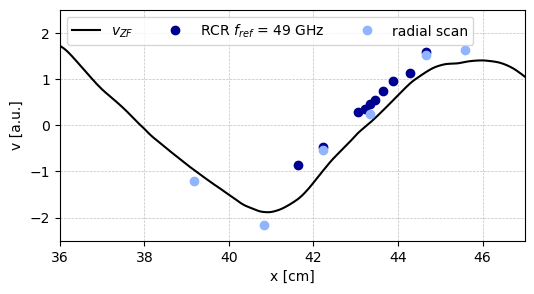

In [163]:
fig, ax = plt.subplots(figsize = (6, 3))
ax.plot(X[-1500:] * rhos * 1e2 , ubar[-1500:], c = 'k', label = r'$v_{ZF}$')

subdir = 'HW_RCR_C1.0_49'
fdop = Struct.from_mat(DATA_FDOP_DIR.joinpath(f'{subdir}.mat'), 'outp')
out = compute_profile(fdop)
ax.plot(xc49 * rhos * 1e2 , out.v_perp / rhos * OmegaI * 1e-10, 'o', c = LPP_palette[0], label = r'RCR $f_{ref}$ = 49 GHz')
subdir = 'HW_RCR_C1.0_51'
fdop = Struct.from_mat(DATA_FDOP_DIR.joinpath(f'{subdir}.mat'), 'outp')
out = compute_profile(fdop)
# ax.plot(xc51 * rhos * 1e2 , out.v_perp / rhos * OmegaI * 1e-10, 'o', c = LPP_palette[2], label = r'RCR $f_{ref}$ = 51 GHz')

fdop = Struct.from_mat(DATA_FDOP_DIR.joinpath(f'HW_rad_scan_C1.0_10.mat'), 'outp')
out = compute_profile(fdop)
xc10 = []
for f0, theta in zip(fdop.freqGHz, fdop.theta):
    nc = get_ncrit(f0 *1e9, angle = np.abs(theta))
    ic = np.argmin(np.abs(ne_lin - nc))
    print(f0, ic)
    # print(X[-1500 + ic] * 1e2 * rhos, ic)
    xc10.append(X[-1500 + ic])
xc10 = np.array(xc10)
ax.plot(xc10 * rhos * 1e2 , out.v_perp / rhos * OmegaI * 1e-10, 'o', c = LPP_palette[1], label = 'radial scan')

subdir = 'HW_RCR_C1.0_51'
fdop = Struct.from_mat(DATA_FDOP_DIR.joinpath(f'{subdir}.mat'), 'outp')
out = compute_profile(fdop)
# ax.plot(xc51 * rhos * 1e2 , out.v_perp / rhos * OmegaI * 1e-10, 'o', c = LPP_palette[2])

ax.set_xlim(36, 47); ax.set_ylim(-2.5,2.5); ax.grid(c = 'silver', ls = '--', lw = 0.5)
ax.set_xlabel('x [cm]'); ax.set_ylabel(r'v [a.u.]')
ax.legend(ncol = 3, loc = 2)

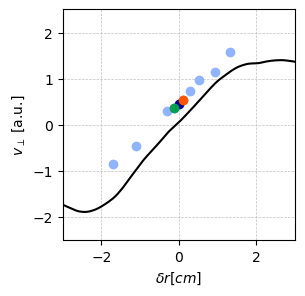

In [293]:
fig, ax = plt.subplots(figsize = (3, 3))

ax.plot((X[-1500:] - xc[isim_ref - 1]) * rhos * 1e2 , ubar[-1500:], c = 'k')
ax.plot(dr , out.v_perp / rhos * OmegaI * 1e-10, 'o', c = LPP_palette[1])
ax.plot(dr[isim_ref -1] , out.v_perp[isim_ref -1] / rhos * OmegaI * 1e-10, 'o', c = LPP_palette[0])
ax.plot(dr[4] , out.v_perp[4] / rhos * OmegaI * 1e-10, 'o', c = LPP_palette[4])
ax.plot(dr[7] , out.v_perp[7] / rhos * OmegaI * 1e-10, 'o', c = LPP_palette[2])

# plt.axvline(xc[isim_ref - 1] * rhos * 1e2, c = 'k')
ax.grid(c = 'silver', ls = '--', lw = 0.5); ax.set_xlim(-3, 3); ax.set_ylim(-2.5,2.5)
ax.set_xlabel(r'$\delta r [cm]$'); ax.set_ylabel(r'$v_\perp$ [a.u.]')
plt.show()

In [155]:
list(dI.params.name)

['HW_test_f47.0_angle10_waist300',
 'HW_test_f48.0_angle10_waist300',
 'HW_test_f48.5_angle10_waist300',
 'HW_test_f49_angle10_waist300',
 'HW_test_f49.2_angle10_waist300',
 'HW_test_f49.5_angle10_waist300',
 'HW_test_f52.0_angle10_waist300',
 'HW_test_f48.8_angle10_waist300',
 'HW_test_f46_angle10_waist300',
 'HW_test_f51_angle10_waist300']

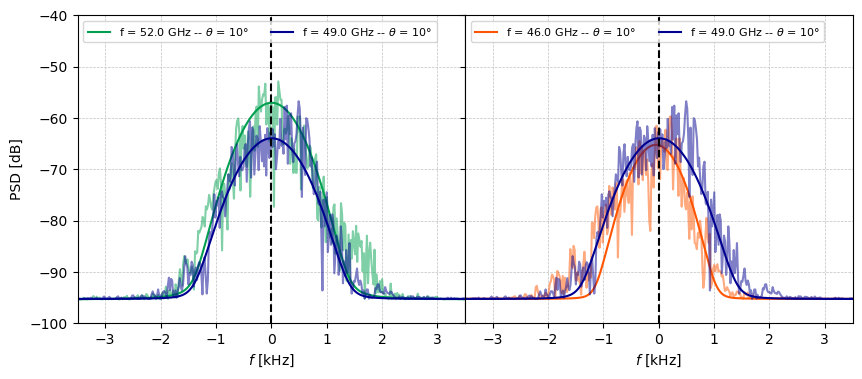

In [275]:
fig, axs = plt.subplots(1, 2, figsize = (10,4), sharey = True)
fdop = Struct.from_mat(DATA_FDOP_DIR.joinpath(f'{subdir}.mat'), 'outp')
out = compute_profile(fdop)

isim = 6
s = out.specobjs[isim]        
xfit = np.linspace(s.f.min(), s.f.max(), 1000)
Tfit = taylor(xfit / s.xscale, *s.fit_params.taylor, dt=s.dt * s.xscale) * s.yscale + s.P_noise
axs[0].plot((s.f  - out.fDop[isim])* 1e-3, 10 * np.log10(s.P + s.P_noise) -4.5, c = LPP_palette[4], alpha = 0.5)
axs[0].plot((xfit - out.fDop[isim]) * 1e-3, 10 * np.log10(Tfit) -4.5, c = LPP_palette[4], label = r'f = %.1f GHz -- $\theta$ = %d°' %(out.freqGHz[isim ], out.theta[isim]))

isim = -2
s = out.specobjs[isim]        
xfit = np.linspace(s.f.min(), s.f.max(), 1000)
Tfit = taylor(xfit / s.xscale, *s.fit_params.taylor, dt=s.dt * s.xscale) * s.yscale + s.P_noise
axs[1].plot((s.f  - out.fDop[isim])* 1e-3, 10 * np.log10(s.P + s.P_noise)-4, c = LPP_palette[2], alpha = 0.5)
axs[1].plot((xfit - out.fDop[isim]) * 1e-3, 10 * np.log10(Tfit)-4, c = LPP_palette[2], label = r'f = %.1f GHz -- $\theta$ = %d°' %(out.freqGHz[isim ], out.theta[isim]))

isim = 3
s = out.specobjs[isim]        
xfit = np.linspace(s.f.min(), s.f.max(), 1000)
Tfit = taylor(xfit / s.xscale, *s.fit_params.taylor, dt=s.dt * s.xscale) * s.yscale + s.P_noise
for ax in axs:
    ax.plot((s.f  - out.fDop[isim])* 1e-3, 10 * np.log10(s.P + s.P_noise), c = LPP_palette[0], alpha = 0.5)
    ax.plot((xfit - out.fDop[isim]) * 1e-3, 10 * np.log10(Tfit), c = LPP_palette[0], label = r'f = %.1f GHz -- $\theta$ = %d°' %(out.freqGHz[isim ], out.theta[isim]))
    ax.axvline(0, c = 'k', ls = '--')
    ax.grid(c = 'silver', ls = '--', lw = 0.5)
    ax.set_xlabel(r'$f $ [kHz]')
    ax.set_xlim(-3.5,3.5)
    ax.legend(loc = 2, ncol = 2, fontsize = 8)

axs[0].set_ylabel(r'PSD [dB]'); axs[0].set_ylim(-100, -40)
fig.subplots_adjust(wspace = 0)

In [ ]:
dI = DataInterface(subdir = subdir, machine = machine)
list(dI.params.name)

['HW_test_f47.0_angle10_waist300',
 'HW_test_f48.0_angle10_waist300',
 'HW_test_f48.5_angle10_waist300',
 'HW_test_f49_angle10_waist300',
 'HW_test_f49.2_angle10_waist300',
 'HW_test_f49.5_angle10_waist300',
 'HW_test_f52.0_angle10_waist300',
 'HW_test_f48.8_angle10_waist300',
 'HW_test_f46_angle10_waist300',
 'HW_test_f51_angle10_waist300']

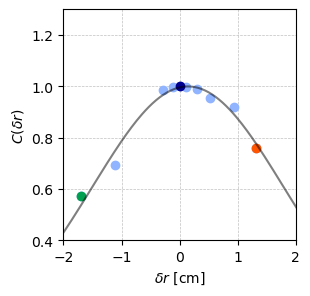

In [123]:
subdir = 'HW_RCR_C1.0_49'
fdop = Struct.from_mat(DATA_FDOP_DIR.joinpath(f'{subdir}.mat'), 'outp')
out = compute_profile(fdop)
dI = DataInterface(subdir = subdir, machine = machine)
inp = InputData.load_pickle(dI.params.name[0], subdir = subdir, machine = machine)
ne_lin = inp.ne.mean(axis = 0)
xc = []
for f0, theta in zip(dI.params.F, dI.params.theta):
    nc = get_ncrit(f0 *1e9, angle = np.abs(theta))
    ic = np.argmin(np.abs(ne_lin - nc))
    xc.append(X[-1500 + ic])

xc = np.array(xc)

isim_ref = 4
s = fdop.specobjs[isim_ref -1]
xfit = np.linspace(s.f.min(), s.f.max(), 1000)
Tfit = taylor(xfit / s.xscale, *s.fit_params.taylor, dt=s.dt * s.xscale) * s.yscale + s.P_noise
C_ref = np.fft.irfft(Tfit)


fig, ax = plt.subplots(figsize = (3,3))
fdop = Struct.from_mat(DATA_FDOP_DIR.joinpath(f'{subdir}.mat'), 'outp')
out = compute_profile(fdop)

C_fit = []
dr    = []
df    = []

for isim in dI.params.isims:
    s = fdop.specobjs[isim -1]
    xfit = np.linspace(s.f.min(), s.f.max(), 1000)
    Tfit = taylor(xfit / s.xscale, *s.fit_params.taylor, dt=s.dt * s.xscale) * s.yscale + s.P_noise
    c = cross_corr(C_ref, np.fft.irfft(Tfit))
    C_fit.append(c)
    dr.append((xc[isim -1] - xc[isim_ref -1] ) * rhos * 1e2)
    df.append(dI.params.F[isim_ref -1] - dI.params.F[isim -1])
    # ax.plot((xc[isim -1] - xc[isim_ref -1]) * rhos * 1e2, c, 'o',  )

C_49 = np.array(C_fit); dr_49 = np.array(dr); df = np.array(df)

ax.plot(dr_49, C_49, 'o', c = LPP_palette[1])
ax.plot(dr_49[6] , C_49[6], 'o', c = LPP_palette[4])
ax.plot(dr_49[-2] , C_49[-2], 'o', c = LPP_palette[2])
ax.plot(dr_49[isim_ref -1], C_fit[isim_ref -1], 'o', c = LPP_palette[0])

ax.set_xlabel(r'$\delta r$ [cm]'); ax.set_ylabel(r'$C(\delta r)$ ');  ax.grid(c = 'silver', lw = 0.5, ls = '--')
ax.set_xlim(-2,2); ax.set_ylim(0.4, 1.3)
ax.plot(dr_fit, shifted_gaussian(dr_fit, *popt_g_49), c = 'k', alpha = 0.5)
plt.show()

Shifted exponential: l_r=3.37 cm, peak at δr=0.20 cm
Shifted Gaussian:    l_r=1.65 cm, peak at δr=0.14 cm


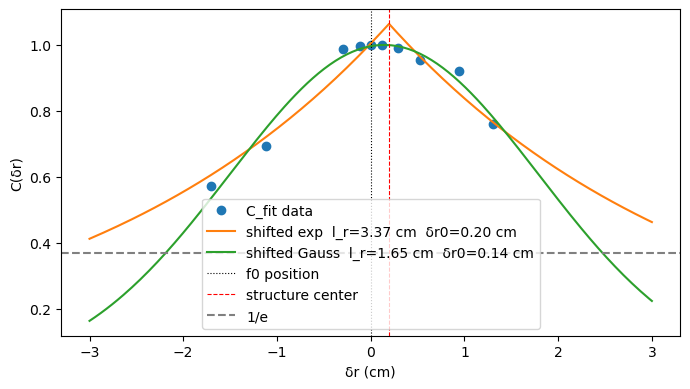

In [122]:
from scipy.optimize import curve_fit

def shifted_exponential(dr, lr, dr0, C0):
    return C0 * np.exp(-np.abs(dr - dr0) / lr)

def shifted_gaussian(dr, lr, dr0, C0):
    return C0 * np.exp(-(dr - dr0)**2 / (2*lr**2))

popt_e, _ = curve_fit(shifted_exponential, dr_49, C_49,
                      p0=[1.0, -1.0, 1.0])
popt_g_49, _ = curve_fit(shifted_gaussian, dr_49, C_49,
                      p0=[1.0, -0.5, 1.0])

lr_e, dr0_e, C0_e = popt_e
lr_g, dr0_g, C0_g = popt_g_49

print(f"Shifted exponential: l_r={lr_e:.2f} cm, peak at δr={dr0_e:.2f} cm")
print(f"Shifted Gaussian:    l_r={lr_g:.2f} cm, peak at δr={dr0_g:.2f} cm")

dr_fit = np.linspace(-3,3, 200)

plt.figure(figsize=(7,4))
plt.plot(dr_49, C_49, 'o', label='C_fit data')
plt.plot(dr_fit, shifted_exponential(dr_fit, *popt_e),
         label=f'shifted exp  l_r={lr_e:.2f} cm  δr0={dr0_e:.2f} cm')
plt.plot(dr_fit, shifted_gaussian(dr_fit, *popt_g_49),
         label=f'shifted Gauss  l_r={lr_g:.2f} cm  δr0={dr0_g:.2f} cm')
plt.axvline(0, color='k', lw=0.8, ls=':', label='f0 position')
plt.axvline(dr0_e, color='r', lw=0.8, ls='--', label='structure center')
plt.axhline(1/np.e, color='gray', ls='--', label='1/e')
plt.xlabel('δr (cm)')
plt.ylabel('C(δr)')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
subdir = 'HW_RCR_C1.0_51'
dI = DataInterface(subdir = subdir, machine = 'irene')

list(dI.params.name)

['HW_test_f50.5_angle10_waist300',
 'HW_test_f51_angle10_waist300',
 'HW_test_f51.2_angle10_waist300',
 'HW_test_f51.5_angle10_waist300',
 'HW_test_f53.0_angle10_waist300',
 'HW_test_f50.8_angle10_waist300',
 'HW_test_f52.0_angle10_waist300',
 'HW_test_f49_angle10_waist300']

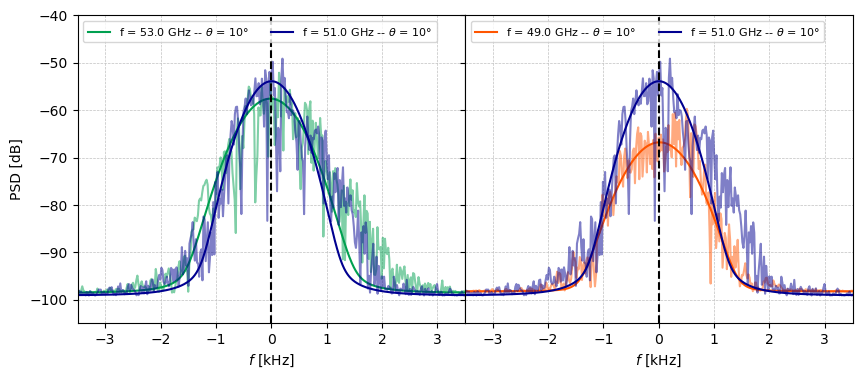

In [98]:
fig, axs = plt.subplots(1, 2, figsize = (10,4), sharey = True)
fdop = Struct.from_mat(DATA_FDOP_DIR.joinpath(f'{subdir}.mat'), 'outp')
out = compute_profile(fdop)

isim = 4
s = out.specobjs[isim]        
xfit = np.linspace(s.f.min(), s.f.max(), 1000)
Tfit = taylor(xfit / s.xscale, *s.fit_params.taylor, dt=s.dt * s.xscale) * s.yscale + s.P_noise
axs[0].plot((s.f  - out.fDop[isim])* 1e-3, 10 * np.log10(s.P + s.P_noise) - 5, c = LPP_palette[4], alpha = 0.5)
axs[0].plot((xfit - out.fDop[isim]) * 1e-3, 10 * np.log10(Tfit) - 5, c = LPP_palette[4], label = r'f = %.1f GHz -- $\theta$ = %d°' %(out.freqGHz[isim ], out.theta[isim]))

isim = -1
s = out.specobjs[isim]        
xfit = np.linspace(s.f.min(), s.f.max(), 1000)
Tfit = taylor(xfit / s.xscale, *s.fit_params.taylor, dt=s.dt * s.xscale) * s.yscale + s.P_noise
axs[1].plot((s.f  - out.fDop[isim])* 1e-3, 10 * np.log10(s.P + s.P_noise) -3, c = LPP_palette[2], alpha = 0.5)
axs[1].plot((xfit - out.fDop[isim]) * 1e-3, 10 * np.log10(Tfit) -3, c = LPP_palette[2], label = r'f = %.1f GHz -- $\theta$ = %d°' %(out.freqGHz[isim ], out.theta[isim]))

isim = 1
s = out.specobjs[isim]        
xfit = np.linspace(s.f.min(), s.f.max(), 1000)
Tfit = taylor(xfit / s.xscale, *s.fit_params.taylor, dt=s.dt * s.xscale) * s.yscale + s.P_noise
for ax in axs:
    ax.plot((s.f  - out.fDop[isim])* 1e-3, 10 * np.log10(s.P + s.P_noise), c = LPP_palette[0], alpha = 0.5)
    ax.plot((xfit - out.fDop[isim]) * 1e-3, 10 * np.log10(Tfit), c = LPP_palette[0], label = r'f = %.1f GHz -- $\theta$ = %d°' %(out.freqGHz[isim ], out.theta[isim]))
    ax.axvline(0, c = 'k', ls = '--')
    ax.grid(c = 'silver', ls = '--', lw = 0.5)
    ax.set_xlabel(r'$f $ [kHz]')
    ax.set_xlim(-3.5,3.5)
    ax.legend(loc = 2, ncol = 2, fontsize = 8)

axs[0].set_ylabel(r'PSD [dB]'); axs[0].set_ylim(-105, -40)
fig.subplots_adjust(wspace = 0)

NameError: name 'popt_g_51' is not defined

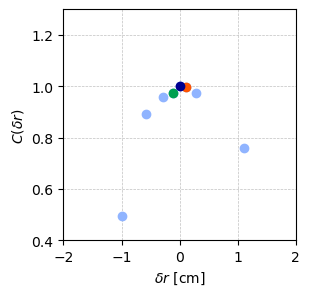

In [124]:
subdir, machine = 'HW_RCR_C1.0_51', 'irene'
fdop = Struct.from_mat(DATA_FDOP_DIR.joinpath(f'{subdir}.mat'), 'outp')
out = compute_profile(fdop)

dI = DataInterface(subdir = subdir, machine = machine)
inp = InputData.load_pickle(dI.params.name[0], subdir = subdir, machine = machine)
ne_lin = inp.ne.mean(axis = 0)
xc = []
for f0, theta in zip(dI.params.F, dI.params.theta):
    nc = get_ncrit(f0 *1e9, angle = np.abs(theta))
    ic = np.argmin(np.abs(ne_lin - nc))
    xc.append(X[-1500 + ic])

xc = np.array(xc)

isim_ref = 2
s = fdop.specobjs[isim_ref -1]
xfit = np.linspace(s.f.min(), s.f.max(), 1000)
Tfit = taylor(xfit / s.xscale, *s.fit_params.taylor, dt=s.dt * s.xscale) * s.yscale + s.P_noise
C_ref = np.fft.irfft(Tfit)


fig, ax = plt.subplots(figsize = (3,3))
fdop = Struct.from_mat(DATA_FDOP_DIR.joinpath(f'{subdir}.mat'), 'outp')
out = compute_profile(fdop)

C_fit = []
dr    = []
df    = []

for isim in dI.params.isims:
    s = fdop.specobjs[isim -1]
    xfit = np.linspace(s.f.min(), s.f.max(), 1000)
    Tfit = taylor(xfit / s.xscale, *s.fit_params.taylor, dt=s.dt * s.xscale) * s.yscale + s.P_noise
    c = cross_corr(C_ref, np.fft.irfft(Tfit))
    C_fit.append(c)
    dr.append((xc[isim -1] - xc[isim_ref -1] ) * rhos * 1e2)
    df.append(dI.params.F[isim_ref -1] - dI.params.F[isim -1])
    # ax.plot((xc[isim -1] - xc[isim_ref -1]) * rhos * 1e2, c, 'o',  )

C_51 = np.array(C_fit); dr_51 = np.array(dr); df = np.array(df)

ax.plot(dr_51, C_51, 'o', c = LPP_palette[1])
ax.plot(dr_51[-3] , C_51[-3], 'o', c = LPP_palette[2])
ax.plot(dr_51[2] , C_51[2], 'o', c = LPP_palette[4])
ax.plot(dr_51[isim_ref -1], C_51[isim_ref -1], 'o', c = LPP_palette[0])

ax.set_xlabel(r'$\delta r$ [cm]'); ax.set_ylabel(r'$C(\delta r)$ ');  ax.grid(c = 'silver', lw = 0.5, ls = '--')
ax.set_xlim(-2,2); ax.set_ylim(0.4, 1.3)
ax.plot(dr_fit, shifted_gaussian(dr_fit, *popt_g_51), c = 'k', alpha = 0.5)

plt.show()

In [144]:
print(list(out.freqGHz))
print(list(xc51))
xc[1]

[50.5, 51.0, 51.2, 51.5, 53.0, 50.800000000000004, 52.0, 49.0]
[40.028263319585115, 39.77049161467518, 39.66001802685664, 39.49430764512883, 38.83146611821758, 39.88096520249373, 39.21812367558247, 40.81999069895134]


39.77049161467518

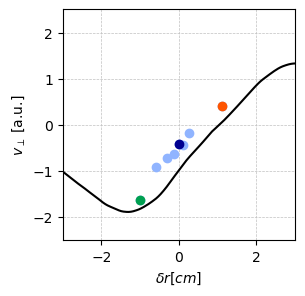

In [116]:
fig, ax = plt.subplots(figsize = (3, 3))
subdir = 'HW_RCR_C1.0_51'
fdop = Struct.from_mat(DATA_FDOP_DIR.joinpath(f'{subdir}.mat'), 'outp')
out = compute_profile(fdop)


ax.plot((X[-1500:] - xc51[1]) * rhos * 1e2 , ubar[-1500:], c = 'k')
ax.plot(dr , out.v_perp / rhos * OmegaI * 1e-10, 'o', c = LPP_palette[1])
ax.plot(dr[1] , out.v_perp[1] / rhos * OmegaI * 1e-10, 'o', c = LPP_palette[0])
ax.plot(dr[4] , out.v_perp[4] / rhos * OmegaI * 1e-10, 'o', c = LPP_palette[4])
ax.plot(dr[7] , out.v_perp[7] / rhos * OmegaI * 1e-10, 'o', c = LPP_palette[2])

# plt.axvline(xc[isim_ref - 1] * rhos * 1e2, c = 'k')
ax.grid(c = 'silver', ls = '--', lw = 0.5); ax.set_xlim(-3, 3); ax.set_ylim(-2.5,2.5)
ax.set_xlabel(r'$\delta r [cm]$'); ax.set_ylabel(r'$v_\perp$ [a.u.]')
plt.show()

Shifted Gaussian:    l_r=1.13 cm, peak at δr=0.20 cm


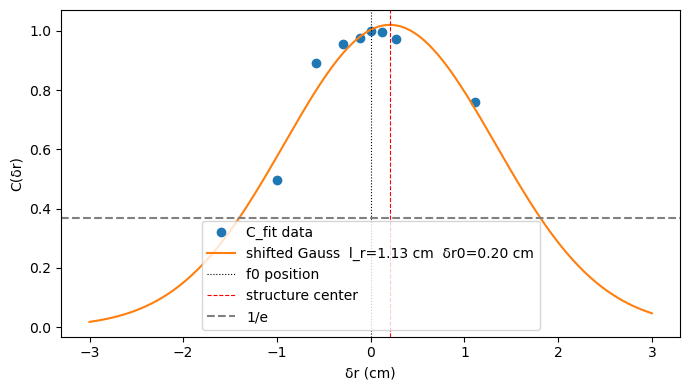

In [126]:
from scipy.optimize import curve_fit

def shifted_exponential(dr, lr, dr0, C0):
    return C0 * np.exp(-np.abs(dr - dr0) / lr)

def shifted_gaussian(dr, lr, dr0, C0):
    return C0 * np.exp(-(dr - dr0)**2 / (2*lr**2))

# popt_e, _ = curve_fit(shifted_exponential, dr, C_fit,
#                       p0=[1.0, -1.0, 1.0])
popt_g_51, _ = curve_fit(shifted_gaussian, dr_51, C_51,
                      p0=[1.0, 0.0, 1.0])

# lr_e, dr0_e, C0_e = popt_e
lr_g, dr0_g, C0_g = popt_g_51

# print(f"Shifted exponential: l_r={lr_e:.2f} cm, peak at δr={dr0_e:.2f} cm")
print(f"Shifted Gaussian:    l_r={lr_g:.2f} cm, peak at δr={dr0_g:.2f} cm")

dr_fit = np.linspace(-3,3, 200)

plt.figure(figsize=(7,4))
plt.plot(dr, C_fit, 'o', label='C_fit data')
# plt.plot(dr_fit, shifted_exponential(dr_fit, *popt_e),
        #  label=f'shifted exp  l_r={lr_e:.2f} cm  δr0={dr0_e:.2f} cm')
plt.plot(dr_fit, shifted_gaussian(dr_fit, *popt_g_51),
         label=f'shifted Gauss  l_r={lr_g:.2f} cm  δr0={dr0_g:.2f} cm')
plt.axvline(0, color='k', lw=0.8, ls=':', label='f0 position')
plt.axvline(dr0_g, color='r', lw=0.8, ls='--', label='structure center')
plt.axhline(1/np.e, color='gray', ls='--', label='1/e')
plt.xlabel('δr (cm)')
plt.ylabel('C(δr)')
plt.legend()
plt.tight_layout()
plt.show()

(0.0, 1.3)

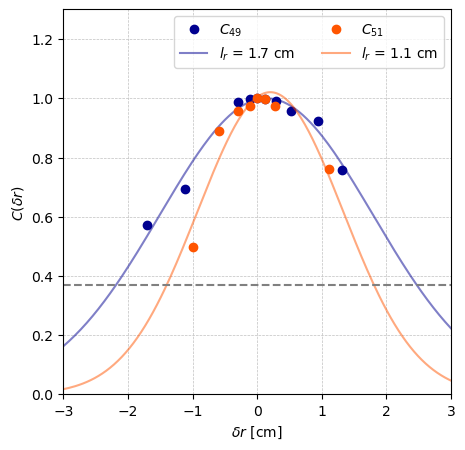

In [139]:
fig, ax = plt.subplots(figsize = (5, 5))

ax.plot(dr_49, C_49, 'o', c = LPP_palette[0], label=r'$C_{49}$ ')
lr_g, dr0_g, C0_g = popt_g_49
ax.plot(dr_fit, shifted_gaussian(dr_fit, *popt_g_49), c = LPP_palette[0], alpha = 0.5, label = r'$l_r$ = %.1f cm' %lr_g )

ax.plot(dr_51, C_51, 'o', c = LPP_palette[2], label=r'$C_{51}$ ')
lr_g, dr0_g, C0_g = popt_g_51
ax.plot(dr_fit, shifted_gaussian(dr_fit, *popt_g_51), c = LPP_palette[2], alpha = 0.5, label = r'$l_r$ = %.1f cm' %lr_g)


ax.legend(ncol = 2)
ax.axhline(1/np.e, color='gray', ls='--', label='1/e')
ax.set_xlabel(r'$\delta r$ [cm]'); ax.set_ylabel(r'$C(\delta r)$ ');  ax.grid(c = 'silver', lw = 0.5, ls = '--')
ax.set_xlim(-3,3); ax.set_ylim(0.0, 1.3)
